# Install Required Libraries

# Stable Library Versions Due to dependencies issues with import Trainer from transformers

1. TODO: Make sure Python Version 3.11.9 is used
2. TODO: Use virtual python environment (.venv) to keep project installations clean

**Use: `pip uninstall -y torch torchvision torchaudio transformers accelerate` if you have any conflicts and then reinstall according to the below versions. These are the main imports**

In [1]:
# Stable Library Versions Due to dependencies issues with import Trainer from transformers

# TODO: Make sure Python Version 3.11.9 is used
# TODO: Use virtual python environment (.venv) to keep project installations clean

# Use: 'pip uninstall -y torch torchvision torchaudio transformers accelerate' if you have any conflicts and then reinstall according to the below versions. These are the main imports

# =========================
# STEP 4: Install GPU PyTorch (CUDA 11.8)
# =========================
%pip install -U pip

# 1. Fix core binary compatibility FIRST
%pip install "numpy<2"

# 2. PyTorch CUDA 11.8 (GPU enabled)
%pip install torch==2.1.2 torchvision==0.16.2 torchaudio==2.1.2 --index-url https://download.pytorch.org/whl/cu118

# 3. HuggingFace ecosystem (compatible set)
%pip install peft==0.7.1 transformers==4.36.2 accelerate==0.27.2 datasets evaluate scikit-learn rouge_score bert_score

# 4. bitsandbytes Windows compatible version
%pip install https://github.com/jllllll/bitsandbytes-windows-webui/releases/download/wheels/bitsandbytes-0.41.1-py3-none-win_amd64.whl

# 5. Optional extras (safe)
%pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cu118
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
     ---------------------------------------- 0.0/152.7 MB ? eta -:--:--
     --------------------------------------- 1.3/152.7 MB 13.4 MB/s eta 0:00:12
     - ------------------------------------- 5.2/152.7 MB 17.7 MB/s eta 0:00:09
     -- ----------------------------------- 10.7/152.7 MB 21.7 MB/s eta 0:00:07
     ---- --------------------------------- 17.0/152.7 MB 23.9 MB/s eta 0:00:06
     ----- -------------------------------- 22.8/152.7 MB 24.9 MB/s eta 0:00:06
     ------- ------------------------------ 28.6/152.7 MB 25.5 MB/s eta 0:00:05
     -------- ----------------------------- 34.6/152.7 MB 26.2 MB/s eta 0:00:05
     ---------- --------------------------- 

## Test that CUDA GPU is being detect and used

In [2]:
import torch
from transformers import Trainer

print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.1.2+cu118
11.8
True
NVIDIA GeForce RTX 3060


# All the Necessary packages can be Imported in this Section

In [3]:
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    BitsAndBytesConfig
)

from peft import get_peft_model, LoraConfig, TaskType, prepare_model_for_kbit_training

import torch
import numpy as np
import accelerate
from datasets import load_dataset, ClassLabel
import evaluate
import time
import json

from rouge_score import rouge_scorer
from bert_score import score as bert_score
from nltk.translate.bleu_score import corpus_bleu
from nltk.translate.meteor_score import meteor_score
import nltk


# Loading the Dataset, Splitting dataset into Train and Test set

In [4]:
# TODO: Change the Filepath to the Complete Dataset
from collections import Counter
file_path = "../../data/dataset.csv"

dataset = load_dataset("csv", data_files=file_path)

# 1. Extract and convert the column values to a standard Python list of integers
binary_values = [1 if val else 0 for val in dataset["train"]["mgt"]]

# 2. Remove the old boolean column
dataset["train"] = dataset["train"].remove_columns("mgt")

# 3. Add the values back under the same column name
dataset["train"] = dataset["train"].add_column("mgt", binary_values)

dataset = dataset["train"].rename_column("mgt", "labels")

dataset = dataset.cast_column("labels", ClassLabel(num_classes=2))

split_dataset = dataset.train_test_split(stratify_by_column="labels", test_size=0.3, seed=42)

print(split_dataset)

train_dataset = split_dataset["train"]

# This is not the Final Step: From here Test is split into Val-/Test- sets
# The final split is 70/15/15
train_eval_dataset = split_dataset["test"]

# test_size = 0.5 because its essentialy size = 0.3/2
train_eval_dataset = train_eval_dataset.train_test_split(
    stratify_by_column="labels", 
    test_size=0.5,
    seed=42,
    )

print(train_eval_dataset)

val_dataset = train_eval_dataset["train"]
test_dataset = train_eval_dataset["test"]

print(train_dataset[:5])
print(val_dataset[:5])
print(test_dataset[:5])

training_set_split = Counter(train_dataset["labels"])
val_set_split = Counter(val_dataset["labels"])
test_set_split = Counter(test_dataset["labels"])


print(f"Training Dataset Label Split: {training_set_split}")
print(f"Validation Dataset Label Split: {val_set_split}")
print(f"Test Dataset Label Split: {test_set_split}")



DatasetDict({
    train: Dataset({
        features: ['id', 'source', 'text', 'labels'],
        num_rows: 9077
    })
    test: Dataset({
        features: ['id', 'source', 'text', 'labels'],
        num_rows: 3891
    })
})
DatasetDict({
    train: Dataset({
        features: ['id', 'source', 'text', 'labels'],
        num_rows: 1945
    })
    test: Dataset({
        features: ['id', 'source', 'text', 'labels'],
        num_rows: 1946
    })
})
{'id': ['test_isizulu_00256', '465', '231', '427', 'train_isizulu_00895'], 'source': ['mistral:7b', 'vukuzenzele', 'vukuzenzele', 'vukuzenzele', 'qwen2.5:7b'], 'text': ['"Ngikuthwasa sikhululekile kwa-inkawu ezilungileyo, ngokuba u-left nxi yamalungelo."', 'I-Surfers Not Street Chi ldren Club inikeza izifundo zokuhuhuluza emagagasini kusukela ngoMsombuluko kuya kuLwesihlanu ngo08h30 kanye nango-13h30. Abanentshisekelo banga bhalisa ehhovisi le-Surfers Not Street Children e-North Beach.', '“Isikhathi esingangonyaka nesigamu manje, abafundi kum

# For BLEU, METEOR, ROUGE-L and BERTScore Calculation Setup & Metric Calculation

In [5]:
import os
import sys
import json
nltk.download("wordnet")

# generated_text - Text that was generated with other LLM's. MGT
# reference_texts = Text that was gathered from datasets. Not MGT (HGT)
def compute_similarity_metrics(generated_texts, reference_texts):
    # BLEU
    references_tokenized  = [[ref.split()] for ref in reference_texts]
    hypotheses_tokenized  = [gen.split() for gen in generated_texts]
    bleu = corpus_bleu(references_tokenized, hypotheses_tokenized)

    # METEOR
    meteor_scores = [
        meteor_score([ref.split()], gen.split())
        for ref, gen in zip(reference_texts, generated_texts)
    ]
    avg_meteor = np.mean(meteor_scores)

    # ROUGE-L
    scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)
    rouge_scores = [
        scorer.score(ref, gen)["rougeL"].fmeasure
        for ref, gen in zip(reference_texts, generated_texts)
    ]
    avg_rouge = np.mean(rouge_scores)

    # BERTScore
    P, R, F1 = bert_score(generated_texts, reference_texts, model_type="bert-base-multilingual-cased")
    avg_bertscore = F1.mean().item()

    return {
        "BLEU":      bleu,
        "METEOR":    avg_meteor,
        "ROUGE-L":   avg_rouge,
        "BERTScore": avg_bertscore,
    }

DIRECTORY_PATH = "../../data/similarity_scores.json"

if not os.path.isfile(DIRECTORY_PATH):
    # Separate texts by class for similarity comparison
    human_texts = [text for text, label in zip(dataset["text"], dataset["labels"]) if label == 0]
    mgt_texts   = [text for text, label in zip(dataset["text"], dataset["labels"]) if label == 1]

    # Lists needs to be of equal size for use
    min_size = min(len(human_texts), len(mgt_texts))
    human_texts = human_texts[:min_size]
    mgt_texts = mgt_texts[:min_size]


    # Compute similarity metrics (MGT vs Human text)
    similarity_results = compute_similarity_metrics(mgt_texts, human_texts)

    with open(DIRECTORY_PATH, "w") as f:
        json.dump(similarity_results, f, indent=4)

    print(f"Similarity Results: {similarity_results}")



[nltk_data] Downloading package wordnet to C:\Users\user-
[nltk_data]     pc\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


# Intialize Model, Prepare setup for training

1. Choose the Correct Model to Train with. 
    1. Use distilbert to ensure your workflow works
    2. Else use your assigned model

In [6]:
# Test Setup with Light Model
#model_id = "distilbert-base-uncased"

#model_id = "Davlan/afro-xlmr-large" # This is the AfroXLMR-large model

# Requires Permission Access on hugging Face
# Make sure you login into huggingface before using
model_id = "Jacaranda/Xhosa_ZuluLlama3_v1" # Xhosa_ZuluLlama3 Model


#model_id = "FacebookAI/xlm-roberta-base" # XLM-RoBERTa-base Model


tokenizer = AutoTokenizer.from_pretrained(model_id)

# This is for QLora
if model_id == "Jacaranda/Xhosa_ZuluLlama3_v1":
    tokenizer.pad_token = tokenizer.eos_token

def preprocess(examples):
  return tokenizer(
        examples["text"],
        truncation=True,
        max_length=128,
        padding=False,
    )

tokenized_train = train_dataset.map(preprocess, batched=True)
tokenized_val = val_dataset.map(preprocess, batched=True)
tokenized_test = test_dataset.map(preprocess, batched=True)

tokenized_train = tokenized_train.remove_columns(["id", "source", "text"])
tokenized_val = tokenized_val.remove_columns(["id", "source", "text"])
tokenized_test  = tokenized_test.remove_columns(["id", "source", "text"])

# Intialize the Specific Model using Model_id. 2 Labels for MGT/Not MGT
model = None
full_trainer = None

c:\Users\user-pc\OneDrive\Desktop\University Files\2026\Semester 1\COS 760 - NLP\COS760-Project-G19\.venv\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


# Determines how much of the tokens are within the nth Percentile

In [7]:
# Calculate token lengths across your dataset
lengths = [len(tokenizer.tokenize(text)) for text in dataset["text"]]

# Find the length that covers 95% of your samples
import numpy as np
optimal_length = int(np.percentile(lengths, 95))
print(f"95th percentile length: {optimal_length}")

95th percentile length: 692


# Trainging and Evaluation Setups

In [8]:
import gc

if 'model' in globals():
    del model

if 'full_trainer' in globals():
    del full_trainer

gc.collect()
torch.cuda.empty_cache()


if model_id == "Jacaranda/Xhosa_ZuluLlama3_v1":
    bnb_config = BitsAndBytesConfig(
        load_in_8bit=True,
        bnb_8bit_compute_dtype=torch.float16,
        #llm_int8_enable_fp32_cpu_offload=True
    )

    '''bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,                        # changed from 8bit to 4bit
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
    )'''

    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=16,
        lora_alpha=32,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj"]
    )

    # Intialize the Specific Model using Model_id. 2 Labels for MGT/Not MGT
    model = AutoModelForSequenceClassification.from_pretrained(
        model_id, 
        num_labels = 2,
        quantization_config=bnb_config,
        device_map={"": 0},
        )

    model.config.pad_token_id = tokenizer.pad_token_id

    model = prepare_model_for_kbit_training(model=model)

    # Attach LoRA adapters on top of quantized model
    model = get_peft_model(model, lora_config)
else:
    model = AutoModelForSequenceClassification.from_pretrained(
        model_id, 
        num_labels = 2,   
        )

print(f"Total parameters to train: {sum(p.numel() for p in model.parameters()):,}")

bin c:\Users\user-pc\OneDrive\Desktop\University Files\2026\Semester 1\COS 760 - NLP\COS760-Project-G19\.venv\Lib\site-packages\bitsandbytes\libbitsandbytes_cuda118.dll


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Some weights of LlamaForSequenceClassification were not initialized from the model checkpoint at Jacaranda/Xhosa_ZuluLlama3_v1 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameters to train: 7,518,572,544


In [ ]:
# Load all classification metrics
accuracy_metric = evaluate.load("accuracy")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")
f1_metric = evaluate.load("f1")


data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy  = accuracy_metric.compute(predictions=predictions, references=labels)
    precision = precision_metric.compute(predictions=predictions, references=labels, average="binary")
    recall    = recall_metric.compute(predictions=predictions, references=labels, average="binary")
    f1        = f1_metric.compute(predictions=predictions, references=labels, average="binary")

    return {
        "accuracy":  accuracy["accuracy"],
        "precision": precision["precision"],
        "recall":    recall["recall"],
        "f1":        f1["f1"],
    }



# Setup Training Arguments
# TrainingArguments for each model were selected based on hardware available to ensure kernels do not crash during training
if model_id == "distilbert-base-uncased":
    print(f"Model Load: {model_id}")
    full_train_args = TrainingArguments(
        output_dir="../../data/full_results/test",
        num_train_epochs=7,
        per_device_train_batch_size=16,    
        per_device_eval_batch_size=16,
        evaluation_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        save_total_limit=2,
        metric_for_best_model="f1",
        weight_decay=0.01,
        warmup_ratio=0.1,
        logging_steps=10,
        fp16=True,  
        dataloader_num_workers=2,
        dataloader_pin_memory=True,                          
        seed=42,
    )
elif model_id == "FacebookAI/xlm-roberta-base":
    print(f"Model Load: {model_id}")
    full_train_args = TrainingArguments(
        output_dir="../../data/full_results/xlmr_base",
        per_device_train_batch_size=16,       # 277M fits comfortably at 16
        per_device_eval_batch_size=16,
        evaluation_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        save_total_limit=2,
        metric_for_best_model="f1",

        logging_steps=10,
        fp16=True,                            # RTX 5060 supports fp16 well
        dataloader_num_workers=2,
        dataloader_pin_memory=True,
        seed=42,
        # Key Parameters
        weight_decay=0.01,                  # Higher = more regularization, lower = less constrained
        warmup_ratio=0.15,                   # Higher = more stable start, lower = faster initial learning
        num_train_epochs=7,                 # Test what works best for Each model
        learning_rate=1e-5,                 # Default learning rate of 5e-5 is aggressive
        lr_scheduler_type="cosine",         # cosine decay is more stable than linear for larger models
        label_smoothing_factor=0.1,         # prevents overconfident predictions on one class

    )
elif model_id == "Davlan/afro-xlmr-large":
    print(f"Model Load: {model_id}")
    full_train_args = TrainingArguments(
        output_dir="../../data/full_results/afro_xlmr",
        
        per_device_train_batch_size=8,        # halved due to larger model size
        per_device_eval_batch_size=8,
        gradient_accumulation_steps=2,        # simulates batch size of 16
        evaluation_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        save_total_limit=2,
        metric_for_best_model="f1",
        logging_steps=10,
        fp16=True,
        dataloader_num_workers=2,
        dataloader_pin_memory=True,
        seed=42,
        # Key Parameters
        weight_decay=0.01,                      # Higher = more regularization, lower = less constrained
        warmup_ratio=0.1,                       # Higher = more stable start, lower = faster initial learning
        num_train_epochs=5,                     # large model converges faster
        learning_rate=2e-5,                     # Default learning rate of 5e-5 is aggressive
        lr_scheduler_type="cosine",             # cosine decay is more stable than linear for larger models
        label_smoothing_factor=0.05,             # prevents overconfident predictions on one class

    )
elif model_id == "Jacaranda/Xhosa_ZuluLlama3_v1":
    print(f"Model Load: {model_id}")
    full_train_args = TrainingArguments(
        output_dir="../../data/full_results/zululLama3",
        per_device_train_batch_size=8,        
        per_device_eval_batch_size=8,
        gradient_accumulation_steps=2,        # simulates batch size of 16
        evaluation_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        save_total_limit=2,
        metric_for_best_model="f1",
        logging_steps=10,
        fp16=True,
        gradient_checkpointing=True,
        dataloader_pin_memory=True,
        dataloader_num_workers=8,
        seed=42,
        optim="paged_adamw_8bit",
        # Key Parameters
        weight_decay=0.01,                      # Higher = more regularization, lower = less constrained
        warmup_ratio=0.1,                       # Higher = more stable start, lower = faster initial learning
        num_train_epochs=3,                   # 8B converges quickly, more risks overfitting
        learning_rate=2e-5,                     # Default learning rate of 5e-5 is aggressive
        lr_scheduler_type="cosine",             # cosine decay is more stable than linear for larger models
        label_smoothing_factor=0.05,             # prevents overconfident predictions on one class
    )
    torch.backends.cuda.enable_flash_sdp(True)
    torch.backends.cuda.enable_mem_efficient_sdp(True)
    torch.backends.cuda.enable_math_sdp(False)
else:
    raise ValueError(f"No TrainingArguments configured for model_id: {model_id}")

full_trainer = Trainer(
    model = model,
    args=full_train_args,
    train_dataset = tokenized_train,
    eval_dataset = tokenized_val,
    data_collator = data_collator,
    compute_metrics = compute_metrics
)

Model Load: Jacaranda/Xhosa_ZuluLlama3_v1


# Train and Evaluate the Model and Calculate Metrics

In [10]:
# Timer to Track Duration
start_time = time.time()

# Train Model
full_trainer.train()

full_duration = time.time() - start_time
print(f"Full Fine-tuning took: {full_duration:.2f} seconds")


  0%|          | 0/1701 [00:00<?, ?it/s]

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...
c:\Users\user-pc\OneDrive\Desktop\University Files\2026\Semester 1\COS 760 - NLP\COS760-Project-G19\.venv\Lib\site-packages\torch\utils\checkpoint.py:429: UserWarning: torch.utils.checkpoint: please pass in use_reentrant=True or use_reentrant=False explicitly. The default value of use_reentrant will be updated to be False in the future. To maintain current behavior, pass use_reentrant=True. It is recommended that you use use_reentrant=False. Refer to docs for more details on the differences between the two variants.
  warnings.warn(
c:\Users\user-pc\OneDrive\Desktop\University Files\2026\Semester 1\COS 760 - NLP\COS760-Project-G19\.venv\Lib\site-packages\bitsandbytes\autograd\_functions.py:322: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


{'loss': 1.1516, 'learning_rate': 8.187134502923977e-07, 'epoch': 0.02}
{'loss': 0.9874, 'learning_rate': 1.9883040935672516e-06, 'epoch': 0.04}
{'loss': 1.1124, 'learning_rate': 3.157894736842105e-06, 'epoch': 0.05}
{'loss': 0.9995, 'learning_rate': 4.3274853801169596e-06, 'epoch': 0.07}
{'loss': 1.0216, 'learning_rate': 5.497076023391813e-06, 'epoch': 0.09}
{'loss': 1.041, 'learning_rate': 6.666666666666667e-06, 'epoch': 0.11}
{'loss': 0.8934, 'learning_rate': 7.836257309941521e-06, 'epoch': 0.12}
{'loss': 0.9999, 'learning_rate': 9.005847953216374e-06, 'epoch': 0.14}
{'loss': 0.975, 'learning_rate': 1.017543859649123e-05, 'epoch': 0.16}
{'loss': 0.9165, 'learning_rate': 1.1345029239766083e-05, 'epoch': 0.18}
{'loss': 0.8931, 'learning_rate': 1.2514619883040937e-05, 'epoch': 0.19}
{'loss': 0.8666, 'learning_rate': 1.3684210526315791e-05, 'epoch': 0.21}
{'loss': 0.8281, 'learning_rate': 1.4853801169590644e-05, 'epoch': 0.23}
{'loss': 0.8237, 'learning_rate': 1.60233918128655e-05, 'epo

  0%|          | 0/244 [00:00<?, ?it/s]

{'eval_loss': 0.5161699652671814, 'eval_accuracy': 0.7645244215938304, 'eval_precision': 0.8220551378446115, 'eval_recall': 0.6748971193415638, 'eval_f1': 0.7412429378531074, 'eval_runtime': 219.3854, 'eval_samples_per_second': 8.866, 'eval_steps_per_second': 1.112, 'epoch': 1.0}


...

{'eval_loss': 0.49210324883461, 'eval_accuracy': 0.774293059125964, 'eval_precision': 0.8352201257861636, 'eval_recall': 0.6831275720164609, 'eval_f1': 0.7515563101301641, 'eval_runtime': 205.6767, 'eval_samples_per_second': 9.457, 'eval_steps_per_second': 1.186, 'epoch': 2.0}


c:\Users\user-pc\OneDrive\Desktop\University Files\2026\Semester 1\COS 760 - NLP\COS760-Project-G19\.venv\Lib\site-packages\torch\utils\checkpoint.py:429: UserWarning: torch.utils.checkpoint: please pass in use_reentrant=True or use_reentrant=False explicitly. The default value of use_reentrant will be updated to be False in the future. To maintain current behavior, pass use_reentrant=True. It is recommended that you use use_reentrant=False. Refer to docs for more details on the differences between the two variants.
  warnings.warn(
c:\Users\user-pc\OneDrive\Desktop\University Files\2026\Semester 1\COS 760 - NLP\COS760-Project-G19\.venv\Lib\site-packages\bitsandbytes\autograd\_functions.py:322: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


{'loss': 0.4567, 'learning_rate': 5.988984650672813e-06, 'epoch': 2.01}
{'loss': 0.4125, 'learning_rate': 5.801751598543947e-06, 'epoch': 2.03}
{'loss': 0.4621, 'learning_rate': 5.616288532109225e-06, 'epoch': 2.04}
{'loss': 0.4039, 'learning_rate': 5.432673642781595e-06, 'epoch': 2.06}
{'loss': 0.4378, 'learning_rate': 5.2509843427806895e-06, 'epoch': 2.08}
{'loss': 0.4205, 'learning_rate': 5.0712972324957686e-06, 'epoch': 2.1}
{'loss': 0.4941, 'learning_rate': 4.893688068190933e-06, 'epoch': 2.11}
{'loss': 0.4674, 'learning_rate': 4.718231730066179e-06, 'epoch': 2.13}
{'loss': 0.3985, 'learning_rate': 4.545002190687865e-06, 'epoch': 2.15}
{'loss': 0.4577, 'learning_rate': 4.374072483801769e-06, 'epoch': 2.17}
{'loss': 0.429, 'learning_rate': 4.205514673542025e-06, 'epoch': 2.19}
{'loss': 0.4374, 'learning_rate': 4.039399824048777e-06, 'epoch': 2.2}
{'loss': 0.4374, 'learning_rate': 3.875797969507502e-06, 'epoch': 2.22}
{'loss': 0.4467, 'learning_rate': 3.7147780846224922e-06, 'epoch'

  0%|          | 0/244 [00:00<?, ?it/s]

{'eval_loss': 0.4907523989677429, 'eval_accuracy': 0.7712082262210797, 'eval_precision': 0.8018327605956472, 'eval_recall': 0.720164609053498, 'eval_f1': 0.7588075880758808, 'eval_runtime': 209.1634, 'eval_samples_per_second': 9.299, 'eval_steps_per_second': 1.167, 'epoch': 3.0}
{'train_runtime': 13283.2319, 'train_samples_per_second': 2.05, 'train_steps_per_second': 0.128, 'train_loss': 0.5331949518751495, 'epoch': 3.0}
Full Fine-tuning took: 13283.41 seconds


# Evaluate Test set of Trained Model

This code section is separate in order to do testing separately

In [11]:
# Predict classification metrics on the Test set to determine generalization
predictions_output = full_trainer.predict(tokenized_test)

c:\Users\user-pc\OneDrive\Desktop\University Files\2026\Semester 1\COS 760 - NLP\COS760-Project-G19\.venv\Lib\site-packages\bitsandbytes\autograd\_functions.py:322: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


  0%|          | 0/244 [00:00<?, ?it/s]

Classification Results:
{
  "test_loss": 0.5007017850875854,
  "test_accuracy": 0.7682425488180884,
  "test_precision": 0.8056206088992974,
  "test_recall": 0.7070914696813977,
  "test_f1": 0.7531472359058566,
  "test_runtime": 219.0844,
  "test_samples_per_second": 8.882,
  "test_steps_per_second": 1.114
}


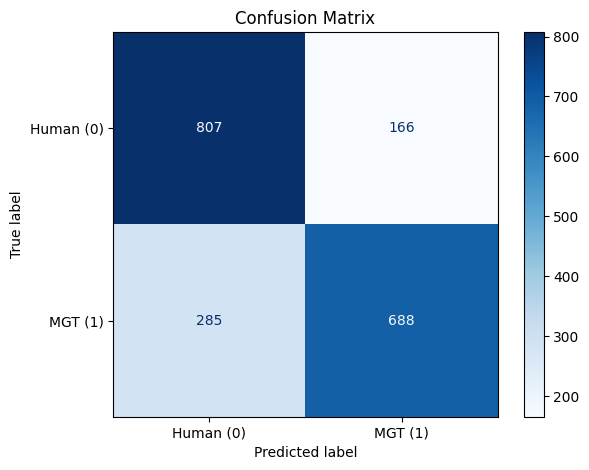

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import json

print("Classification Results:")
print(json.dumps(predictions_output.metrics, indent=2))

# Get predictions on test set
logits = predictions_output.predictions
predicted_labels = np.argmax(logits, axis=-1)
label_counts = np.bincount(predicted_labels)

# Get true labels from test set
true_labels = np.array(tokenized_test["labels"])

# Compute confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Human (0)", "MGT (1)"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()